# Assignment 6: Comparing AI-Based Style Transfer Methods

**Objective:** Compare CycleGAN and VGG19-based Neural Style Transfer using a completely different content image and different artistic style inputs.

**New examples used in this notebook:**
- Content image: a city skyline photograph
- CycleGAN target domain: Japanese Ukiyo-e style
- Neural Style Transfer reference: Hokusai's *The Great Wave off Kanagawa*


## Step 1: Install and Import Libraries

In [1]:
!pip install torch torchvision pillow requests -q

import os
import sys
import urllib.request
import requests
from io import BytesIO

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


## Step 2: Load a New Content Image

A city skyline photograph is used instead of the landscape/mountain image from the original notebook.

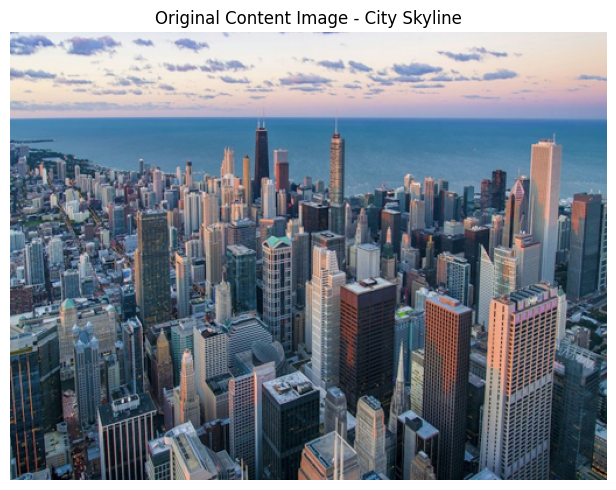

Content image loaded successfully.
Image size: (512, 384)


In [2]:
# New content image: city skyline
content_url = "https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?w=768"

response = requests.get(content_url, timeout=30)
response.raise_for_status()

content_image = Image.open(BytesIO(response.content)).convert("RGB")
content_image = content_image.resize((512, 384))

content_image.save("city_original.jpg")

plt.figure(figsize=(7, 5))
plt.imshow(content_image)
plt.title("Original Content Image - City Skyline")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Content image loaded successfully.")
print("Image size:", content_image.size)


## Step 3: Clone the CycleGAN Repository

In [3]:
# Clone CycleGAN
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git -q

%cd pytorch-CycleGAN-and-pix2pix

!pip install -r requirements.txt -q
!pip install dominate visdom -q


/content/pytorch-CycleGAN-and-pix2pix
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.0 MB/s eta 0:00:00


## Step 4: Download a Different Pretrained CycleGAN Model

The original notebook uses Monet style. This version uses the **Ukiyo-e** style model instead.

In [4]:
import os

# Download the pretrained Ukiyo-e CycleGAN model
!bash scripts/download_cyclegan_model.sh style_ukiyoe

print("Pretrained Ukiyo-e CycleGAN model downloaded.")


Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_ukiyoe]
for details.

--2026-10-05 12:40:40--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_ukiyoe.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_ukiyoe_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  27.4MB/s    in 1.6s    

2026-10-05 12:40:42 (27.4 MB/s) - ‘./checkpoints/style_ukiyoe_pretrained/latest_net_G.pth’ saved [45575747/45575747]

Pret

## Step 5: Load the CycleGAN Generator

In [6]:
import torch
from models.networks import define_G

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Create the same generator architecture used by the pretrained model
netG = define_G(
    input_nc=3,
    output_nc=3,
    ngf=64,
    netG="resnet_9blocks",
    norm="instance",
    use_dropout=False,
    init_type="normal",
    init_gain=0.02
)

checkpoint_path = "./checkpoints/style_ukiyoe_pretrained/latest_net_G.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Handle checkpoints saved with or without a state_dict wrapper
if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    checkpoint = checkpoint["state_dict"]

netG.load_state_dict(checkpoint, strict=False)
netG.eval()
netG = netG.to(device)

print("Ukiyo-e CycleGAN generator loaded successfully.")

Device: cuda
Ukiyo-e CycleGAN generator loaded successfully.


## Step 6: Generate the New CycleGAN Output

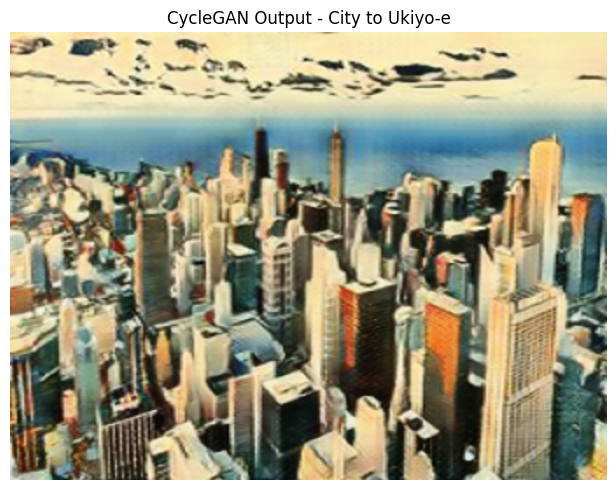

CycleGAN output saved.


In [7]:
# Prepare the city image for CycleGAN
cycle_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

input_tensor = cycle_transform(content_image).unsqueeze(0).to(device)

with torch.no_grad():
    output_tensor = netG(input_tensor)

# Convert the generated tensor back into an image
output_tensor = output_tensor.squeeze(0).cpu()
output_tensor = output_tensor * 0.5 + 0.5
output_tensor = output_tensor.clamp(0, 1)

output_np = output_tensor.permute(1, 2, 0).numpy()

cyclegan_image = Image.fromarray(
    (output_np * 255).astype("uint8")
).resize((512, 384))

cyclegan_image.save("city_ukiyoe_cyclegan.jpg")

plt.figure(figsize=(7, 5))
plt.imshow(cyclegan_image)
plt.title("CycleGAN Output - City to Ukiyo-e")
plt.axis("off")
plt.tight_layout()
plt.show()

print("CycleGAN output saved.")


## Step 7: Load VGG19 for Neural Style Transfer

A second, independent style-transfer method is implemented using VGG19 feature representations.

In [8]:
# Load VGG19 using the current torchvision weights API
weights = models.VGG19_Weights.DEFAULT
vgg = models.vgg19(weights=weights).features.to(device).eval()

# Freeze VGG parameters
for parameter in vgg.parameters():
    parameter.requires_grad_(False)

print("VGG19 loaded successfully.")


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 76.3MB/s]


VGG19 loaded successfully.


## Step 8: Load a Different Style Reference

The Neural Style Transfer example uses Hokusai's **The Great Wave off Kanagawa**, rather than Van Gogh's *Starry Night*.

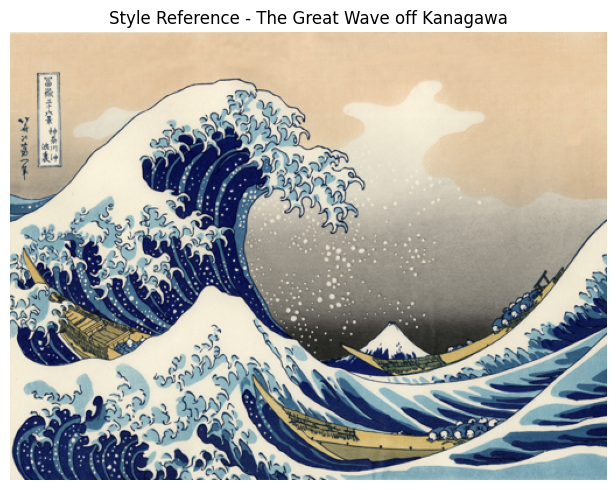

Style image loaded successfully.


In [10]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Hokusai - The Great Wave off Kanagawa
style_url = (
    "https://upload.wikimedia.org/wikipedia/commons/0/0a/"
    "The_Great_Wave_off_Kanagawa.jpg"
)

# Download image with a browser-like User-Agent
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(style_url, headers=headers)

if response.status_code == 200:
    style_image = Image.open(BytesIO(response.content)).convert("RGB")
    style_image = style_image.resize((512, 384))

    plt.figure(figsize=(7, 5))
    plt.imshow(style_image)
    plt.title("Style Reference - The Great Wave off Kanagawa")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("Style image loaded successfully.")
else:
    print("Failed to download image.")
    print("Status code:", response.status_code)

## Step 9: Perform Neural Style Transfer

In [11]:
def get_features(image_tensor, model):
    layers = {
        "0": "conv1_1",
        "5": "conv2_1",
        "10": "conv3_1",
        "19": "conv4_1",
        "21": "conv4_2",
        "28": "conv5_1"
    }

    features = {}
    x = image_tensor

    for name, layer in model._modules.items():
        x = layer(x)

        if name in layers:
            features[layers[name]] = x

    return features


def gram_matrix(tensor):
    batch_size, channels, height, width = tensor.size()
    tensor = tensor.view(channels, height * width)

    return torch.mm(tensor, tensor.t())


def image_to_tensor(image):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    return transform(image).unsqueeze(0).to(device)


# Convert both images to tensors
content_tensor = image_to_tensor(content_image)
style_tensor = image_to_tensor(style_image)

# Extract VGG19 features
content_features = get_features(content_tensor, vgg)
style_features = get_features(style_tensor, vgg)

# Calculate Gram matrices for the style image
style_grams = {
    layer: gram_matrix(style_features[layer])
    for layer in style_features
}

# Start from a copy of the city image
target = content_tensor.clone().requires_grad_(True)

# Loss weights
style_weight = 1e6
content_weight = 1

style_weights = {
    "conv1_1": 1.0,
    "conv2_1": 0.75,
    "conv3_1": 0.2,
    "conv4_1": 0.2,
    "conv5_1": 0.2
}

optimizer = optim.Adam([target], lr=0.003)

print("Starting Neural Style Transfer...")

steps = 300

for step in range(1, steps + 1):

    target_features = get_features(target, vgg)

    # Content loss
    content_loss = torch.mean(
        (target_features["conv4_2"] -
         content_features["conv4_2"]) ** 2
    )

    # Style loss
    style_loss = 0

    for layer in style_weights:
        target_gram = gram_matrix(target_features[layer])
        style_gram = style_grams[layer]

        layer_loss = style_weights[layer] * torch.mean(
            (target_gram - style_gram) ** 2
        )

        style_loss += layer_loss

    total_loss = (
        content_weight * content_loss +
        style_weight * style_loss
    )

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(
            "Step [{}/{}] | Total Loss: {:.2f} | "
            "Content Loss: {:.4f} | Style Loss: {:.4f}".format(
                step,
                steps,
                total_loss.item(),
                content_loss.item(),
                style_loss.item()
            )
        )

print("Neural Style Transfer optimization complete.")


Starting Neural Style Transfer...
Step [50/300] | Total Loss: 1248370093981696.00 | Content Loss: 6.8938 | Style Loss: 1248370048.0000
Step [100/300] | Total Loss: 682221664993280.00 | Content Loss: 8.8355 | Style Loss: 682221696.0000
Step [150/300] | Total Loss: 436621308592128.00 | Content Loss: 9.9859 | Style Loss: 436621312.0000
Step [200/300] | Total Loss: 312987453751296.00 | Content Loss: 10.7270 | Style Loss: 312987456.0000
Step [250/300] | Total Loss: 243455271895040.00 | Content Loss: 11.2844 | Style Loss: 243455280.0000
Step [300/300] | Total Loss: 199968509919232.00 | Content Loss: 11.7345 | Style Loss: 199968512.0000
Neural Style Transfer optimization complete.


## Step 10: Display the Neural Style Transfer Output

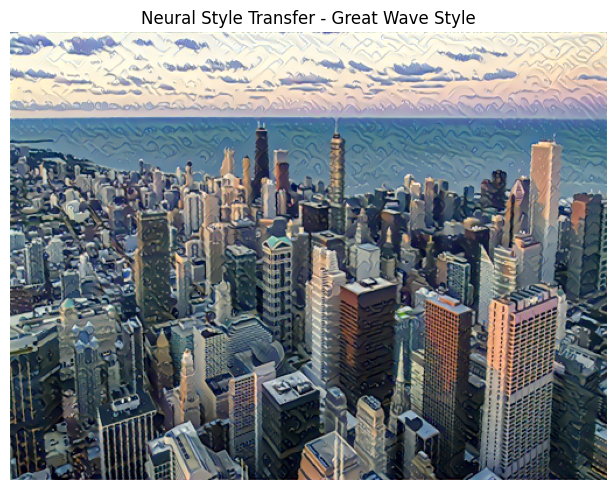

NST output saved.


In [12]:
def tensor_to_image(tensor):
    image = tensor.detach().cpu().squeeze(0)
    image = image.numpy().transpose(1, 2, 0)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    return image


nst_output = tensor_to_image(target)

nst_image = Image.fromarray(
    (nst_output * 255).astype("uint8")
)

nst_image.save("city_great_wave_nst.jpg")

plt.figure(figsize=(7, 5))
plt.imshow(nst_output)
plt.title("Neural Style Transfer - Great Wave Style")
plt.axis("off")
plt.tight_layout()
plt.show()

print("NST output saved.")


## Step 11: Compare the Two Methods

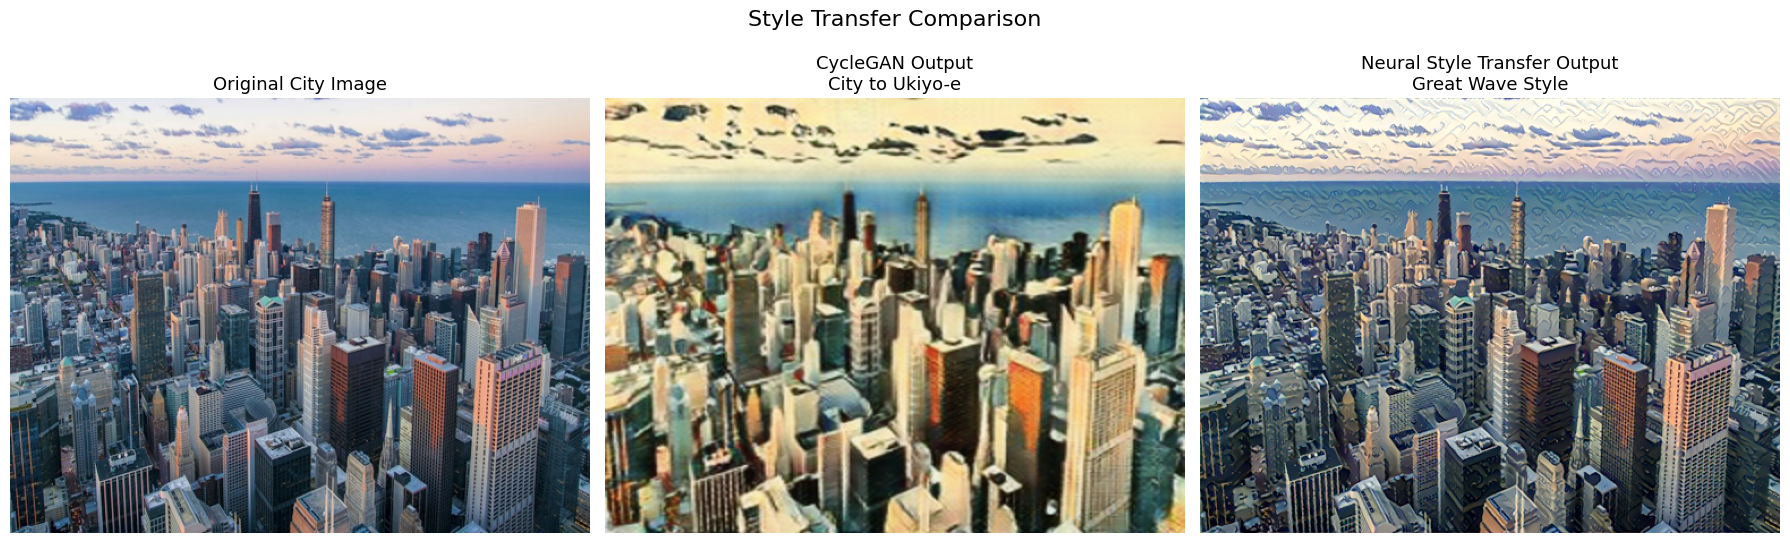

Comparison image saved.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(content_image)
axes[0].set_title("Original City Image", fontsize=13)
axes[0].axis("off")

axes[1].imshow(cyclegan_image)
axes[1].set_title(
    "CycleGAN Output\nCity to Ukiyo-e",
    fontsize=13
)
axes[1].axis("off")

axes[2].imshow(nst_output)
axes[2].set_title(
    "Neural Style Transfer Output\nGreat Wave Style",
    fontsize=13
)
axes[2].axis("off")

plt.suptitle("Style Transfer Comparison", fontsize=16)
plt.tight_layout()

plt.savefig("city_style_transfer_comparison.jpg", bbox_inches="tight")
plt.show()

print("Comparison image saved.")


## Step 12: Analysis and Conclusion

### Which method preserved the original content better?

Neural Style Transfer generally preserves the structure of the city image more closely because it explicitly minimizes a content loss based on VGG19 feature representations. Major objects and the spatial arrangement of the original photograph therefore remain recognizable.

### Which method produced the stronger style transformation?

CycleGAN performs a domain-level transformation. Because the model was trained to translate photographs toward the Ukiyo-e domain, it can change the overall colour palette, texture, edges, and visual appearance of the city scene in a more coherent way.

### What differences can be observed?

The two methods use different ideas. CycleGAN learns a mapping between two image domains, while Neural Style Transfer optimizes a single image so that its content features resemble the original image and its texture statistics resemble the chosen style reference.

In this experiment, the inputs are intentionally different from the original assignment: a city skyline is used as the content image, Ukiyo-e is used for CycleGAN, and Hokusai's *The Great Wave off Kanagawa* is used as the Neural Style Transfer reference.
